In [1]:
import requests
import pandas as pd
from pathlib import Path


OUT_DIR = Path("api_column_checks")
OUT_DIR.mkdir(exist_ok=True)


def show_columns(name, url, params=None):
    print(f"\n--- {name} ---")
    print("URL:", url)
    print("PARAMS:", params)

    r = requests.get(url, params=params, timeout=60)
    print("STATUS:", r.status_code)
    r.raise_for_status()

    payload = r.json()

    if isinstance(payload, dict) and "data" in payload:
        records = payload["data"]
    elif isinstance(payload, dict) and "result" in payload and "records" in payload["result"]:
        records = payload["result"]["records"]
    elif isinstance(payload, list):
        records = payload
    else:
        print("Unknown response shape:")
        print(payload.keys() if isinstance(payload, dict) else type(payload))
        return

    df = pd.DataFrame(records)

    print("ROWS:", len(df))
    print("COLUMNS:")
    for c in df.columns:
        print("  -", c)

    df.head(5).to_csv(OUT_DIR / f"{name}_sample.csv", index=False)


# ============================================================
# 1. NESO Historic Demand Data
# ============================================================

# Example: 2023 Historic Demand Data resource
# NESO uses CKAN datastore_search for its data portal resources.
# Source docs: NESO Historic Demand Data + NESO API guidance.
show_columns(
    name="neso_historic_demand_2023",
    url="https://api.neso.energy/api/3/action/datastore_search",
    params={
        "resource_id": "bf5ab335-9b40-4ea4-b93a-ab4af7bce003",
        "limit": 5,
    }
)


# ============================================================
# 2. Elexon BM Units reference
# ============================================================

# This should show fields like:
# nationalGridBmUnit, elexonBmUnit, fuelType, gspGroupId, gspGroupName, etc.
show_columns(
    name="elexon_bmunits_reference",
    url="https://data.elexon.co.uk/bmrs/api/v1/reference/bmunits/all",
    params={
        "format": "json"
    }
)


# ============================================================
# 3. Elexon B1610 generation
# ============================================================

# B1610 stream: actual metered volume output per BMU per settlement period.
# Small one-day request only, just to inspect columns.
show_columns(
    name="elexon_b1610_sample",
    url="https://data.elexon.co.uk/bmrs/api/v1/datasets/B1610/stream",
    params={
        "from": "2023-01-01T00:00Z",
        "to": "2023-01-02T00:00Z",
        "settlementPeriodFrom": 1,
        "settlementPeriodTo": 48,
        "format": "json",
    }
)


--- neso_historic_demand_2023 ---
URL: https://api.neso.energy/api/3/action/datastore_search
PARAMS: {'resource_id': 'bf5ab335-9b40-4ea4-b93a-ab4af7bce003', 'limit': 5}
STATUS: 200
ROWS: 5
COLUMNS:
  - _id
  - SETTLEMENT_DATE
  - SETTLEMENT_PERIOD
  - ND
  - TSD
  - ENGLAND_WALES_DEMAND
  - EMBEDDED_WIND_GENERATION
  - EMBEDDED_WIND_CAPACITY
  - EMBEDDED_SOLAR_GENERATION
  - EMBEDDED_SOLAR_CAPACITY
  - NON_BM_STOR
  - PUMP_STORAGE_PUMPING
  - SCOTTISH_TRANSFER
  - IFA_FLOW
  - IFA2_FLOW
  - BRITNED_FLOW
  - MOYLE_FLOW
  - EAST_WEST_FLOW
  - NEMO_FLOW
  - NSL_FLOW
  - ELECLINK_FLOW
  - VIKING_FLOW
  - GREENLINK_FLOW

--- elexon_bmunits_reference ---
URL: https://data.elexon.co.uk/bmrs/api/v1/reference/bmunits/all
PARAMS: {'format': 'json'}
STATUS: 200
ROWS: 3004
COLUMNS:
  - nationalGridBmUnit
  - elexonBmUnit
  - eic
  - fuelType
  - leadPartyName
  - bmUnitType
  - fpnFlag
  - bmUnitName
  - leadPartyId
  - demandCapacity
  - generationCapacity
  - productionOrConsumptionFlag
  - tra

Scottish transfer summary:
count    31344.000000
mean      1686.058576
std       1817.039015
min      -2851.000000
25%        152.750000
50%       1531.000000
75%       3055.000000
max       6586.000000
Name: scottish_transfer_mw, dtype: float64

Most common Scottish transfer values:
scottish_transfer_mw
0       1345
785       15
1135      14
1313      14
650       14
2922      13
298       13
863       13
2164      13
2081      13
Name: count, dtype: int64


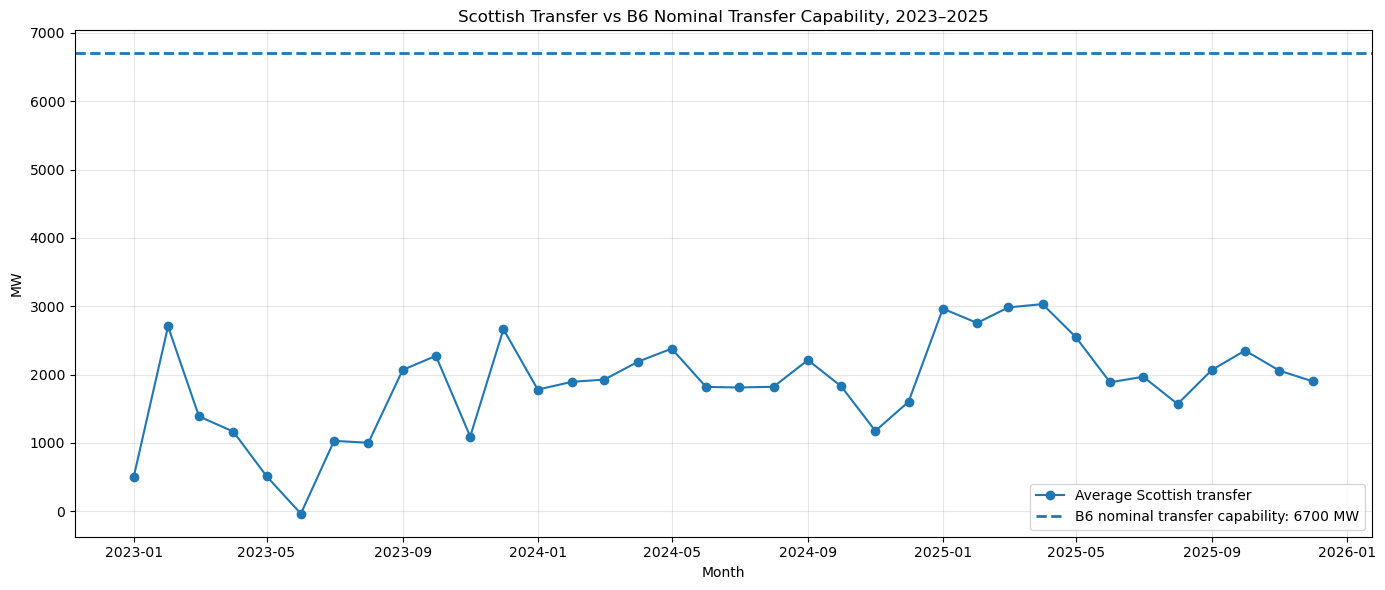

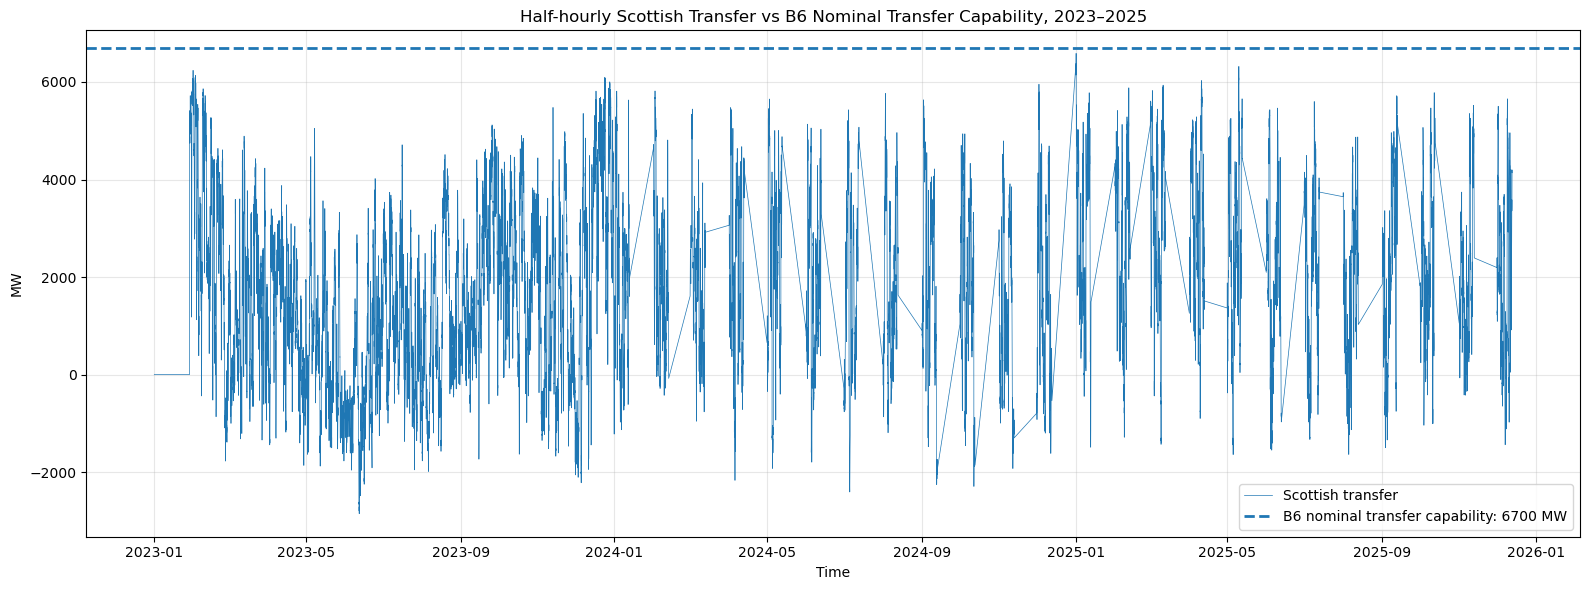

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# SETTINGS
# ============================================================

CSV_PATH = Path("demand data/final/ew_residual_demand_half_hourly.csv")

OUT_DIR = Path("demand data/final/plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

B6_NOMINAL_LIMIT_MW = 6700


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(CSV_PATH)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["scottish_transfer_mw"] = pd.to_numeric(
    df["scottish_transfer_mw"],
    errors="coerce"
)

df = df.sort_values("timestamp").reset_index(drop=True)


# ============================================================
# CHECK DATA
# ============================================================

print("Scottish transfer summary:")
print(df["scottish_transfer_mw"].describe())

print("\nMost common Scottish transfer values:")
print(df["scottish_transfer_mw"].value_counts().head(10))

if df["scottish_transfer_mw"].nunique(dropna=True) <= 1:
    print(
        "\nWARNING: scottish_transfer_mw is constant. "
        "If it is all zero, this column is not useful as actual transfer."
    )


# ============================================================
# MONTHLY AVERAGE GRAPH
# ============================================================

monthly = df.copy()
monthly["month"] = monthly["timestamp"].dt.to_period("M").dt.to_timestamp()

monthly = (
    monthly
    .groupby("month", as_index=False)
    .agg(
        avg_scottish_transfer_mw=("scottish_transfer_mw", "mean")
    )
)

monthly["b6_nominal_limit_mw"] = B6_NOMINAL_LIMIT_MW

plt.figure(figsize=(14, 6))

plt.plot(
    monthly["month"],
    monthly["avg_scottish_transfer_mw"],
    marker="o",
    label="Average Scottish transfer"
)

plt.axhline(
    y=B6_NOMINAL_LIMIT_MW,
    linestyle="--",
    linewidth=2,
    label="B6 nominal transfer capability: 6700 MW"
)

plt.title("Scottish Transfer vs B6 Nominal Transfer Capability, 2023–2025")
plt.xlabel("Month")
plt.ylabel("MW")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUT_DIR / "monthly_scottish_transfer_vs_b6_nominal_limit.png",
    dpi=300
)

plt.show()


# ============================================================
# HALF-HOURLY GRAPH
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    df["timestamp"],
    df["scottish_transfer_mw"],
    linewidth=0.5,
    label="Scottish transfer"
)

plt.axhline(
    y=B6_NOMINAL_LIMIT_MW,
    linestyle="--",
    linewidth=2,
    label="B6 nominal transfer capability: 6700 MW"
)

plt.title("Half-hourly Scottish Transfer vs B6 Nominal Transfer Capability, 2023–2025")
plt.xlabel("Time")
plt.ylabel("MW")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUT_DIR / "half_hourly_scottish_transfer_vs_b6_nominal_limit.png",
    dpi=300
)

plt.show()